# ICTLB Replication
**Paper:** *Imbalanced Clustering With Theoretical Learning Bounds*  
Zhang, Tao, Hou — IEEE TKDE Vol. 35 No. 9, September 2023

---
**Subset replicated**
| | Paper | This notebook |
|---|---|---|
| Datasets | 14 | 4 (haberman, ecoli3, vowel0, shuttle-2vs5) |
| Methods | 8 | 4 (k-means, k-means++, MACW, ICTLB) |
| Runs | 10 | 10 |
| α | −1/2 | −0.5 ✓ |
| W strategy | fix one=2, tune other | W_fixed=2, tune ∈ {0.1,0.2,0.3,1,2,3} ✓ |
| Norm | L2 | L2 ✓ |
| Init | density-k-means++ | density-k-means++ ✓ |

All technical details are handled by the `src/` package.  
All settings are controlled by `config.yaml`.

## 1 · Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd())

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

from src import ExperimentPipeline, METHOD_DISPLAY_NAMES

CONFIG = 'config.yaml'
pipeline = ExperimentPipeline(CONFIG)
print('Pipeline ready.')
print(f'  Datasets : {pipeline.datasets}')
print(f'  Methods  : {pipeline.methods}')
print(f'  Runs     : {pipeline.n_runs}')

Pipeline ready.
  Datasets : ['haberman', 'ecoli3', 'vowel0', 'shuttle-2vs5']
  Methods  : ['kmeans', 'kmeanspp', 'macw', 'ictlb']
  Runs     : 10


## 2 · Dataset Overview

In [2]:
info_df = pipeline.get_dataset_info()
info_df = info_df.set_index('Dataset')
display(info_df.style
        .set_caption('Datasets used (Table II subset, Zhang et al. 2023)')
        .format({'IR': '{:.2f}'}))

,Samples,Features,k,IR,Minority,Majority
Dataset,,,,,,
haberman,306,3,2,2.78,81,225
ecoli3,336,7,2,8.60,35,301
vowel0,988,10,2,9.98,90,898
shuttle-2vs5,3316,9,2,66.67,49,3267


## 3 · Run Experiment

> **Estimated time:** ~20–30 min (single-core CPU).  
> Results are cached in `results/` — re-run only if you change `config.yaml`.
>
> To load cached results instead of re-running, skip this cell and run the
> *Load cached* cell below.

In [3]:
raw = pipeline.run(verbose=True)

Starting experiment: 4 datasets × 4 methods × 10 runs = 160 total runs

── haberman ....
── ecoli3 ....
── vowel0 ....
── shuttle-2vs5 ....

Done.

Results saved to: /home/doanhtran03/Python/sentourism-experiment/papers/Imbalanced Clustering With Theoretical Learning Bounds/results


In [4]:
# ── Load cached results (run this cell instead of the one above to skip re-running) ──
# raw = pd.read_csv('results/raw_results.csv')
# print(f'Loaded {len(raw)} rows from cache.')

In [5]:
summary = pipeline.get_summary(raw)
print(f'Summary shape: {summary.shape}  (dataset × method, metrics averaged over {pipeline.n_runs} runs)')
display(summary.head(8))

Summary shape: (16, 5)  (dataset × method, metrics averaged over 10 runs)


ACC  F-score  Recall     DCV  time_s
dataset  method                                           
ecoli3   ictlb     0.8935   0.4797  0.5025  0.9917  0.0070
         kmeans    0.7265   0.6229  0.8347  0.2565  0.0024
         kmeanspp  0.7265   0.6229  0.8347  0.2565  0.0021
         macw      0.7976   0.6113  0.7368  0.5286  0.0030
haberman ictlb     0.6859   0.4341  0.4783  0.8621  0.0071
         kmeans    0.5127   0.4801  0.5071  0.0307  0.0028
         kmeanspp  0.5611   0.5097  0.5293  0.1627  0.0046
         macw      0.5621   0.4671  0.4699  0.3634  0.0025

## 4 · Per-Dataset Results

Each table corresponds to one dataset.  
**Bold** = best value per column (metric).  
For ACC / F-score / Recall: higher is better.  
For DCV: larger indicates a more distorted cluster-size distribution (worse).

In [6]:
METRICS   = ['ACC', 'F-score', 'Recall', 'DCV']
HIGHER_IS_BETTER = ['ACC', 'F-score', 'Recall']   # DCV: larger = worse

def _bold_best(df: pd.DataFrame) -> pd.io.formats.style.Styler:
    """Bold the best value in each column (highest for ACC/F/R, lowest for DCV)."""
    def _highlight(col):
        if col.name in HIGHER_IS_BETTER:
            is_best = col == col.max()
        else:  # DCV
            is_best = col == col.min()
        return ['font-weight: bold' if v else '' for v in is_best]
    return df.style.apply(_highlight, axis=0).format('{:.4f}')


for ds in pipeline.datasets:
    ds_df = summary.loc[ds, METRICS].copy()
    ds_df.index = [METHOD_DISPLAY_NAMES.get(m, m) for m in ds_df.index]
    from src.data import DATASETS
    meta = DATASETS[ds]
    caption = (f'{ds}  —  n={meta["n"]}, d={meta["n_features"]}, '
               f'k={meta["k"]}, IR={meta["IR"]}')
    print(f'\n{caption}')
    display(_bold_best(ds_df))


haberman  —  n=306, d=3, k=2, IR=2.78


,ACC,F-score,Recall,DCV
ICTLB,0.6859,0.4341,0.4783,0.8621
k-means,0.5127,0.4801,0.5071,0.0307
k-means++,0.5611,0.5097,0.5293,0.1627
MACW,0.5621,0.4671,0.4699,0.3634



ecoli3  —  n=336, d=7, k=2, IR=8.6


,ACC,F-score,Recall,DCV
ICTLB,0.8935,0.4797,0.5025,0.9917
k-means,0.7265,0.6229,0.8347,0.2565
k-means++,0.7265,0.6229,0.8347,0.2565
MACW,0.7976,0.6113,0.7368,0.5286



vowel0  —  n=988, d=10, k=2, IR=9.98


,ACC,F-score,Recall,DCV
ICTLB,0.9091,0.5100,0.5211,0.9834
k-means,0.7618,0.6356,0.8390,0.3658
k-means++,0.7337,0.6156,0.8415,0.2949
MACW,0.9114,0.5751,0.5604,0.9573



shuttle-2vs5  —  n=3316, d=9, k=2, IR=66.67


,ACC,F-score,Recall,DCV
ICTLB,0.8540,0.4585,0.4334,0.7376
k-means,0.7174,0.4376,0.5651,0.4403
k-means++,0.7169,0.4374,0.5649,0.4393
MACW,0.7462,0.4310,0.4239,0.5166


## 5 · Aggregate Ranking

Rank each method per dataset per metric (1 = best).  
Mean rank across all datasets — lower is better.

In [7]:
rank_rows = []
for ds in pipeline.datasets:
    ds_df = summary.loc[ds, METRICS].copy()
    for metric in METRICS:
        col = ds_df[metric]
        if metric in HIGHER_IS_BETTER:
            ranks = col.rank(ascending=False, method='min')
        else:
            ranks = col.rank(ascending=True, method='min')   # DCV: lower=better
        for method_key, rank_val in ranks.items():
            rank_rows.append({'dataset': ds, 'method': method_key,
                              'metric': metric, 'rank': rank_val})

rank_df = pd.DataFrame(rank_rows)
mean_rank = (rank_df.groupby(['method', 'metric'])['rank']
               .mean()
               .unstack('metric')
               .round(2))
mean_rank.index = [METHOD_DISPLAY_NAMES.get(m, m) for m in mean_rank.index]

def _bold_min(df):
    return df.style.apply(lambda col: ['font-weight: bold' if v == col.min() else ''
                                       for v in col], axis=0).format('{:.2f}')

print('Mean rank across datasets (lower = better for all columns)')
display(_bold_min(mean_rank[METRICS]))

Mean rank across datasets (lower = better for all columns)


metric,ACC,F-score,Recall,DCV
ICTLB,1.25,3.25,3.50,4.00
k-means,3.25,1.50,1.50,1.50
k-means++,3.50,1.75,1.25,1.25
MACW,1.75,3.25,3.50,3.00


## 6 · Comparison With Paper

Tables III–VI in the paper are vector-image graphics — **exact numbers cannot be extracted**.  
Comparison is against the paper's own text claims (Section IV-D, pp. 9606–9607).

- **Paper claim** = what the paper text says ICTLB should achieve on that metric  
- **Replicated rank** = ICTLB's rank among the 4 replicated methods  
- **Match ✓** = claim verified by replication  |  **✗** = claim not reproduced

In [8]:
cmp_df = pipeline.compare_with_paper(summary)

def _colour_match(df):
    def _row_colour(row):
        colour = 'background-color: #d4edda' if row['Match'] == '✓' \
                 else 'background-color: #f8d7da'
        return [colour] * len(row)
    return (df.style
              .apply(_row_colour, axis=1)
              .set_caption('Replication vs. paper claims (qualitative)'))

display(_colour_match(cmp_df.drop(columns=['Paper notes'])))

matched = (cmp_df['Match'] == '✓').sum()
total   = len(cmp_df)
print(f'\nClaims verified: {matched}/{total}')

,Dataset,Metric,Paper claim (ICTLB),ICTLB value,Best method,Replicated rank,Match
0,haberman,ACC,Best,0.685900,ICTLB,Rank 1,✓
1,haberman,F-score,Best,0.434100,k-means++,Rank 4,✗
2,haberman,Recall,Not best,0.478300,k-means++,Rank 3,✓
3,ecoli3,ACC,Best,0.893500,ICTLB,Rank 1,✓
4,ecoli3,F-score,Best,0.479700,k-means,Rank 4,✗
5,ecoli3,Recall,Not best,0.502500,k-means,Rank 4,✓
6,vowel0,ACC,Best,0.909100,MACW,Rank 2,✗
7,vowel0,F-score,Best,0.510000,k-means,Rank 4,✗
8,vowel0,Recall,Best,0.521100,k-means++,Rank 4,✗
9,shuttle-2vs5,ACC,Best,0.854000,ICTLB,Rank 1,✓



Claims verified: 7/12


### Paper notes per dataset

In [9]:
for ds in pipeline.datasets:
    note = cmp_df.loc[cmp_df['Dataset']==ds, 'Paper notes'].iloc[0]
    print(f'  {ds:15s}: {note}')

  haberman       : ICTLB best ACC + F-score; Recall lower than k-means
  ecoli3         : ICTLB best ACC + F-score; Recall lower than MACW
  vowel0         : ICTLB best on ALL three metrics — cleanest win in the paper
  shuttle-2vs5   : ICTLB best ACC + F-score; Recall tied with other methods


## 7 · Visualisation

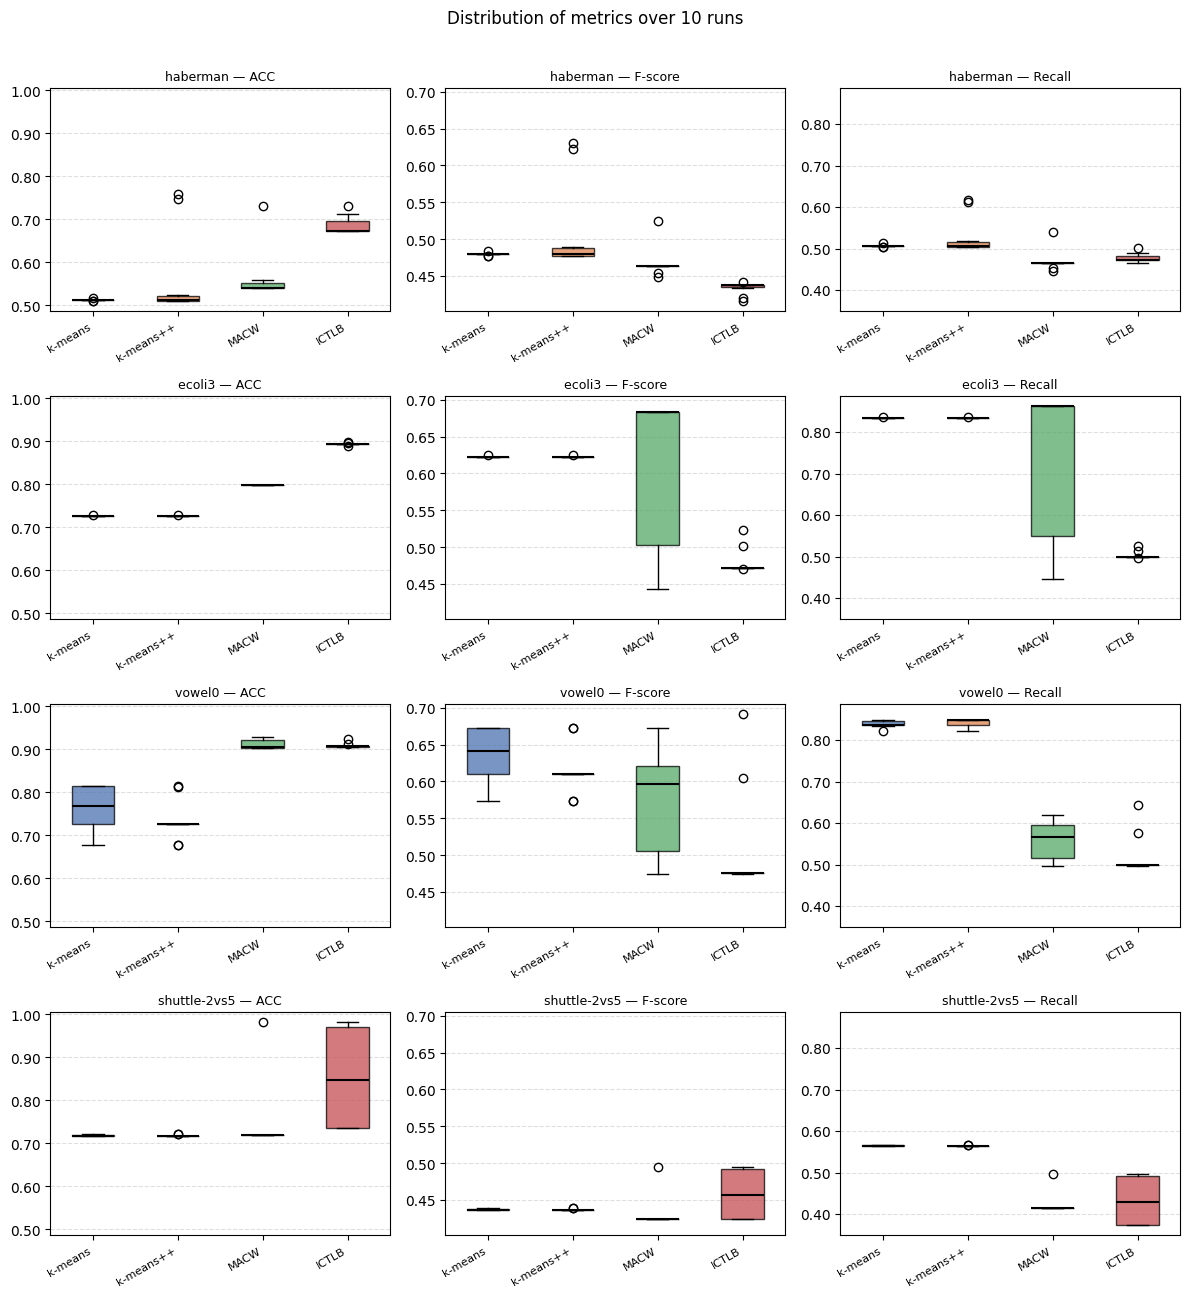

Figure saved to results/metric_distributions.png


In [10]:
PLOT_METRICS = ['ACC', 'F-score', 'Recall']
methods_ordered = pipeline.methods
method_labels   = [METHOD_DISPLAY_NAMES.get(m, m) for m in methods_ordered]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(
    nrows=len(pipeline.datasets), ncols=len(PLOT_METRICS),
    figsize=(12, 3.2 * len(pipeline.datasets)),
    sharey='col'
)
if len(pipeline.datasets) == 1:
    axes = [axes]

for row_idx, ds in enumerate(pipeline.datasets):
    ds_raw = raw[raw['dataset'] == ds]
    for col_idx, metric in enumerate(PLOT_METRICS):
        ax = axes[row_idx][col_idx]
        vals = [ds_raw[ds_raw['method'] == m][metric].values for m in methods_ordered]
        bp = ax.boxplot(vals, patch_artist=True, widths=0.5,
                        medianprops=dict(color='black', linewidth=1.5))
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.75)
        ax.set_xticks(range(1, len(methods_ordered)+1))
        ax.set_xticklabels(method_labels, rotation=30, ha='right', fontsize=8)
        ax.set_title(f'{ds} — {metric}', fontsize=9)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
        ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('Distribution of metrics over 10 runs', fontsize=12, y=1.01)
fig.tight_layout()
plt.savefig('results/metric_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved to results/metric_distributions.png')

## 8 · Key Observations

In [11]:
print('=== Key Observations ===')

# 1. Does ICTLB rank 1st in ACC across all datasets?
ictlb_acc_ranks = []
for ds in pipeline.datasets:
    col = summary.loc[ds, 'ACC']
    rank = list(col.sort_values(ascending=False).index).index('ictlb') + 1
    ictlb_acc_ranks.append(rank)
print(f'\n1. ICTLB ACC rank per dataset: '
      + ', '.join(f'{ds}={r}' for ds, r in zip(pipeline.datasets, ictlb_acc_ranks)))
print(f'   → Mean ACC rank: {np.mean(ictlb_acc_ranks):.2f}  (paper claim: rank 1 on all)')

# 2. Does ICTLB > MACW in ACC on all datasets?
ictlb_vs_macw = []
for ds in pipeline.datasets:
    ictlb_acc = summary.loc[(ds, 'ictlb'), 'ACC']
    macw_acc  = summary.loc[(ds, 'macw'),  'ACC']
    ictlb_vs_macw.append(ictlb_acc > macw_acc)
print(f'\n2. ICTLB > MACW in ACC: {sum(ictlb_vs_macw)}/{len(pipeline.datasets)} datasets')
print(f'   → Paper claim: ICTLB consistently improves on MACW')

# 3. DCV: is k-means smaller than ICTLB? (uniform effect → near-equal sizes → low DCV)
km_dcv    = [summary.loc[(ds, 'kmeans'), 'DCV'] for ds in pipeline.datasets]
ictlb_dcv = [summary.loc[(ds, 'ictlb'), 'DCV'] for ds in pipeline.datasets]
print(f'\n3. DCV comparison:')
for ds, km_v, ic_v in zip(pipeline.datasets, km_dcv, ictlb_dcv):
    print(f'   {ds:15s}: k-means DCV={km_v:.3f}  ICTLB DCV={ic_v:.3f}')
print(f'   → Paper claim: k-means shows uniform effect (low DCV but poor Recall)')

# 4. vowel0: ICTLB best on all three metrics?
if 'vowel0' in pipeline.datasets:
    vowel_summary = summary.loc['vowel0', ['ACC','F-score','Recall']]
    best_per_metric = {m: vowel_summary[m].idxmax() for m in ['ACC','F-score','Recall']}
    all_ictlb = all(v == 'ictlb' for v in best_per_metric.values())
    print(f'\n4. vowel0 best method per metric: {best_per_metric}')
    print(f'   → Paper claim: ICTLB best on ALL three metrics. Verified: {all_ictlb}')

=== Key Observations ===

1. ICTLB ACC rank per dataset: haberman=1, ecoli3=1, vowel0=2, shuttle-2vs5=1
   → Mean ACC rank: 1.25  (paper claim: rank 1 on all)

2. ICTLB > MACW in ACC: 3/4 datasets
   → Paper claim: ICTLB consistently improves on MACW

3. DCV comparison:
   haberman       : k-means DCV=0.031  ICTLB DCV=0.862
   ecoli3         : k-means DCV=0.257  ICTLB DCV=0.992
   vowel0         : k-means DCV=0.366  ICTLB DCV=0.983
   shuttle-2vs5   : k-means DCV=0.440  ICTLB DCV=0.738
   → Paper claim: k-means shows uniform effect (low DCV but poor Recall)

4. vowel0 best method per metric: {'ACC': 'macw', 'F-score': 'kmeans', 'Recall': 'kmeanspp'}
   → Paper claim: ICTLB best on ALL three metrics. Verified: False
